In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path

In [18]:
RESULTS_PATH = Path(r"D:\ibrand_superprototype\eval\comparison\judge\judge_results.csv")

SUMMARY_PATH = Path(r"D:\ibrand_superprototype\eval\comparison\judge\judge_summary.json")


In [19]:
print("Results exists:", RESULTS_PATH.exists())
print("Summary exists:", SUMMARY_PATH.exists())

Results exists: True
Summary exists: True


In [20]:
judge_df = pd.read_csv(RESULTS_PATH)

with open(SUMMARY_PATH, "r", encoding="utf-8") as f:
    judge_summary = json.load(f)

judge_df.head()

,case_id,bad_id,fragrance_id,music_id,condition,mismatch_type,expected_result,judge_run_ok,judge_parse_ok,judge_schema_ok,...,judge_pass_before_rules,critical_rule_violation,critical_rule_names,final_fragrance_score,final_music_score,final_system_pass,correct_decision,judge_latency_ms,deepseek_reason,error
0,M01,2,2,2,matched,none,pass,1,1,1,...,1,0,NaN,5,5,1,1,8615,The fragrance concept aligns perfectly with th...,NaN
1,M02,4,4,4,matched,none,pass,1,1,1,...,1,0,NaN,4,5,1,1,17614,The fragrance concept aligns well with the BAD...,NaN
2,M03,10,10,10,matched,none,pass,1,1,1,...,1,0,NaN,5,4,1,1,7036,The fragrance concept excellently matches the ...,NaN
3,M04,11,11,11,matched,none,pass,1,1,1,...,1,0,NaN,5,5,1,1,6892,The fragrance concept excellently matches the ...,NaN
4,M05,15,15,15,matched,none,pass,1,1,1,...,1,0,NaN,5,4,1,1,6534,The fragrance concept excellently matches the ...,NaN


In [21]:
print("Rows:", len(judge_df))
print("Columns:", judge_df.columns.tolist())

Rows: 12
Columns: ['case_id', 'bad_id', 'fragrance_id', 'music_id', 'condition', 'mismatch_type', 'expected_result', 'judge_run_ok', 'judge_parse_ok', 'judge_schema_ok', 'deepseek_fragrance_score', 'deepseek_music_score', 'deepseek_fragrance_aligns', 'deepseek_music_aligns', 'deepseek_only_pass', 'judge_pass_before_rules', 'critical_rule_violation', 'critical_rule_names', 'final_fragrance_score', 'final_music_score', 'final_system_pass', 'correct_decision', 'judge_latency_ms', 'deepseek_reason', 'error']


In [22]:
judge_df["condition"].value_counts()

condition
matched       6
mismatched    6
Name: count, dtype: int64

In [23]:
pd.crosstab(
    judge_df["condition"],
    judge_df["mismatch_type"]
)

mismatch_type,fragrance,music,none
condition,,,
matched,0,0,6
mismatched,3,3,0


In [24]:
judge_metrics = pd.DataFrame({
    "Metric": [
        "Matched Acceptance Rate",
        "Mismatch Rejection Rate",
        "Overall Correct Decision Rate",
        "Music Mismatch Rejection Rate",
        "Fragrance Mismatch Rejection Rate",
        "Run Success Rate",
        "Parse Success Rate",
        "Schema Success Rate",
    ],
    "Value": [
        judge_summary["matched_acceptance_rate"] * 100,
        judge_summary["mismatch_rejection_rate"] * 100,
        judge_summary["overall_correct_decision_rate"] * 100,
        judge_summary["music_mismatch_rejection_rate"] * 100,
        judge_summary["fragrance_mismatch_rejection_rate"] * 100,
        judge_summary["judge_run_success_rate"] * 100,
        judge_summary["judge_parse_success_rate"] * 100,
        judge_summary["judge_schema_success_rate"] * 100,
    ]
})

judge_metrics

,Metric,Value
0,Matched Acceptance Rate,83.33
1,Mismatch Rejection Rate,83.33
2,Overall Correct Decision Rate,83.33
3,Music Mismatch Rejection Rate,100.00
4,Fragrance Mismatch Rejection Rate,66.67
5,Run Success Rate,100.00
6,Parse Success Rate,100.00
7,Schema Success Rate,100.00


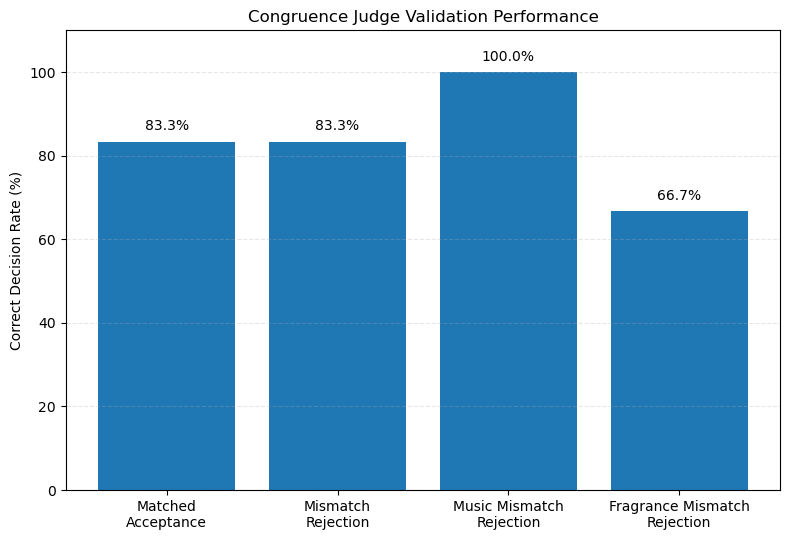

In [25]:
main_metrics = {
    "Matched\nAcceptance": judge_summary["matched_acceptance_rate"] * 100,
    "Mismatch\nRejection": judge_summary["mismatch_rejection_rate"] * 100,
    "Music Mismatch\nRejection": judge_summary["music_mismatch_rejection_rate"] * 100,
    "Fragrance Mismatch\nRejection": judge_summary["fragrance_mismatch_rejection_rate"] * 100,
}

fig, ax = plt.subplots(figsize=(8, 5.5))

bars = ax.bar(
    main_metrics.keys(),
    main_metrics.values()
)

ax.set_title("Congruence Judge Validation Performance")
ax.set_ylabel("Correct Decision Rate (%)")
ax.set_ylim(0, 110)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

for bar in bars:
    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 2,
        f"{height:.1f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [26]:
failed_cases = judge_df[
    judge_df["correct_decision"] == 0
][[
    "case_id",
    "condition",
    "mismatch_type",
    "expected_result",
    "deepseek_fragrance_score",
    "deepseek_music_score",
    "deepseek_fragrance_aligns",
    "deepseek_music_aligns",
    "final_system_pass",
    "deepseek_reason"
]]

failed_cases

,case_id,condition,mismatch_type,expected_result,deepseek_fragrance_score,deepseek_music_score,deepseek_fragrance_aligns,deepseek_music_aligns,final_system_pass,deepseek_reason
5,M06,matched,none,pass,5,3,1,0,0,"The fragrance perfectly aligns with the BAD, m..."
11,X06,mismatched,fragrance,fail,4,5,1,1,1,The fragrance aligns well with the BAD's mood ...


In [27]:
judge_df["expected_label"] = judge_df["expected_result"].map({
    "pass": "Pass",
    "fail": "Fail"
})

judge_df["predicted_label"] = judge_df["final_system_pass"].map({
    1: "Pass",
    0: "Fail"
})

In [28]:
confusion = pd.crosstab(
    judge_df["expected_label"],
    judge_df["predicted_label"],
    rownames=["Expected"],
    colnames=["Judge Decision"]
)

confusion

Judge Decision,Fail,Pass
Expected,,
Fail,5,1
Pass,1,5


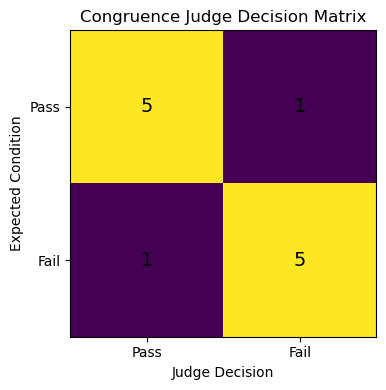

In [29]:
matrix = confusion.reindex(
    index=["Pass", "Fail"],
    columns=["Pass", "Fail"],
    fill_value=0
)

fig, ax = plt.subplots(figsize=(5, 4))

im = ax.imshow(matrix.values)

ax.set_xticks([0, 1])
ax.set_xticklabels(["Pass", "Fail"])

ax.set_yticks([0, 1])
ax.set_yticklabels(["Pass", "Fail"])

ax.set_xlabel("Judge Decision")
ax.set_ylabel("Expected Condition")
ax.set_title("Congruence Judge Decision Matrix")

for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        ax.text(
            j,
            i,
            matrix.iloc[i, j],
            ha="center",
            va="center",
            fontsize=14
        )

plt.tight_layout()
plt.show()

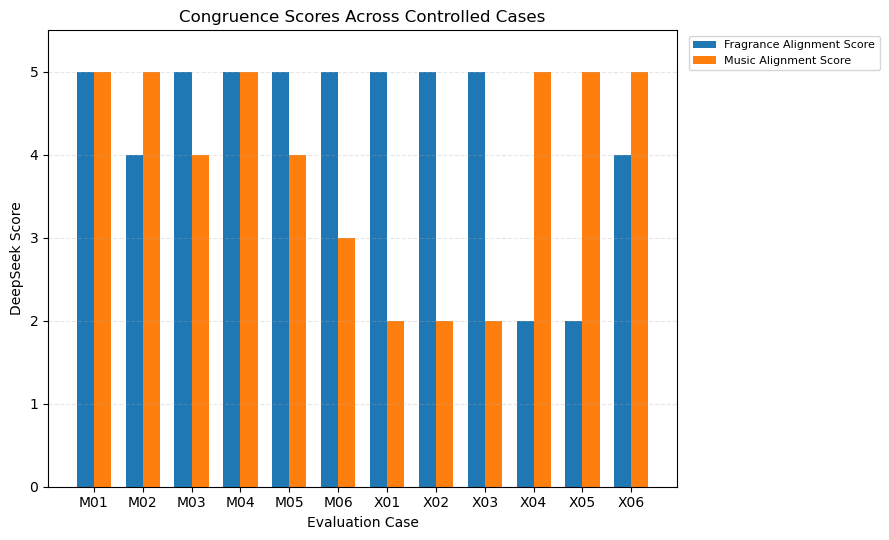

In [30]:
case_order = judge_df["case_id"]

x = np.arange(len(judge_df))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5.5))

bars1 = ax.bar(
    x - width / 2,
    judge_df["deepseek_fragrance_score"],
    width,
    label="Fragrance Alignment Score"
)

bars2 = ax.bar(
    x + width / 2,
    judge_df["deepseek_music_score"],
    width,
    label="Music Alignment Score"
)

ax.set_xticks(x)
ax.set_xticklabels(case_order)

ax.set_xlabel("Evaluation Case")
ax.set_ylabel("DeepSeek Score")
ax.set_title("Congruence Scores Across Controlled Cases")

ax.set_ylim(0, 5.5)

ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.01, 1.0),
    fontsize=8
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()

In [32]:
judge_df["judge_latency_seconds"] = (
    judge_df["judge_latency_ms"] / 1000
)

In [33]:
median_latency = judge_df["judge_latency_seconds"].median()
mean_latency = judge_df["judge_latency_seconds"].mean()

print(f"Median latency: {median_latency:.2f} s")
print(f"Mean latency: {mean_latency:.2f} s")

Median latency: 9.22 s
Mean latency: 10.88 s


In [34]:
report_summary = pd.DataFrame({
    "Metric": [
        "Evaluation Cases",
        "Matched Acceptance Rate",
        "Mismatch Rejection Rate",
        "Music Mismatch Rejection Rate",
        "Fragrance Mismatch Rejection Rate",
        "Overall Correct Decision Rate",
        "Run Success Rate",
        "Parse Success Rate",
        "Schema Success Rate",
        "Median Judge Latency",
        "Deterministic Overrides"
    ],
    "Result": [
        judge_summary["n_cases"],
        f'{judge_summary["matched_acceptance_rate"] * 100:.1f}%',
        f'{judge_summary["mismatch_rejection_rate"] * 100:.1f}%',
        f'{judge_summary["music_mismatch_rejection_rate"] * 100:.1f}%',
        f'{judge_summary["fragrance_mismatch_rejection_rate"] * 100:.1f}%',
        f'{judge_summary["overall_correct_decision_rate"] * 100:.1f}%',
        f'{judge_summary["judge_run_success_rate"] * 100:.1f}%',
        f'{judge_summary["judge_parse_success_rate"] * 100:.1f}%',
        f'{judge_summary["judge_schema_success_rate"] * 100:.1f}%',
        f'{judge_summary["median_judge_latency_ms"] / 1000:.2f} s',
        judge_summary["deterministic_override_count"]
    ]
})

report_summary

,Metric,Result
0,Evaluation Cases,12
1,Matched Acceptance Rate,83.3%
2,Mismatch Rejection Rate,83.3%
3,Music Mismatch Rejection Rate,100.0%
4,Fragrance Mismatch Rejection Rate,66.7%
5,Overall Correct Decision Rate,83.3%
6,Run Success Rate,100.0%
7,Parse Success Rate,100.0%
8,Schema Success Rate,100.0%
9,Median Judge Latency,9.22 s
